In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [2]:
credit_df = pd.read_csv(r"C:\Users\ni\Desktop\credit_risk_predictor\cleaned_data\credit_data.csv")
credit_df

,credit_limit,default,current_outstanding_balance,avg_bill_amount,total_paid,payment_ratio,num_late_payments,avg_delay,max_delay,recent_delay,credit_utilization
0,20000.0,1,3913.0,1284.000000,689.0,0.089422,2,-0.333333,2,2,0.195640
1,120000.0,1,2682.0,2846.166667,5000.0,0.292774,2,0.500000,2,-1,0.022350
2,90000.0,0,29239.0,16942.166667,11018.0,0.108387,0,0.000000,0,0,0.324874
3,50000.0,0,46990.0,38555.666667,8388.0,0.036259,0,0.000000,0,0,0.939781
4,50000.0,0,8617.0,18223.166667,59049.0,0.540049,0,-0.333333,0,-1,0.172337
...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,0,188948.0,120891.500000,42550.0,0.058661,0,0.000000,0,0,0.858851
29996,150000.0,0,1683.0,3530.333333,14490.0,0.684039,0,-0.666667,0,-1,0.011220
29997,30000.0,1,3565.0,11749.333333,31300.0,0.443991,3,1.333333,4,4,0.118829
29998,80000.0,1,-1645.0,44435.166667,147181.0,0.552042,1,-0.166667,1,1,-0.020562


In [3]:
"""
Check distribution of default (target variable)
"""

credit_df["default"].value_counts()
credit_df["default"].value_counts(normalize=True)

default
0    0.7788
1    0.2212
Name: proportion, dtype: float64

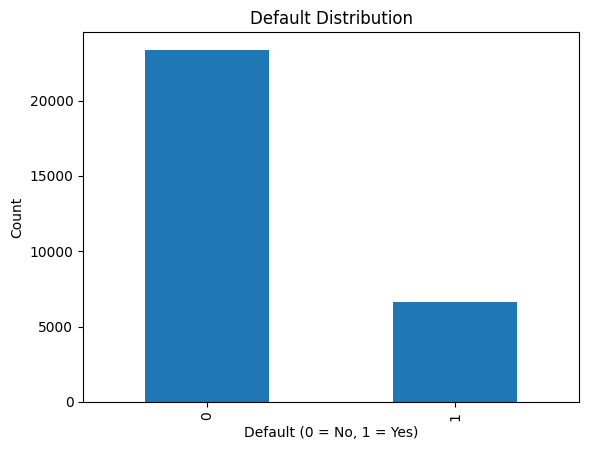

In [4]:
"""
Visualize target distribution
"""

credit_df["default"].value_counts().plot(kind="bar")
plt.title("Default Distribution")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [6]:
# The distribution looks imbalanced with almost 77% of data is of non_default customers and 22% of them defaulting.

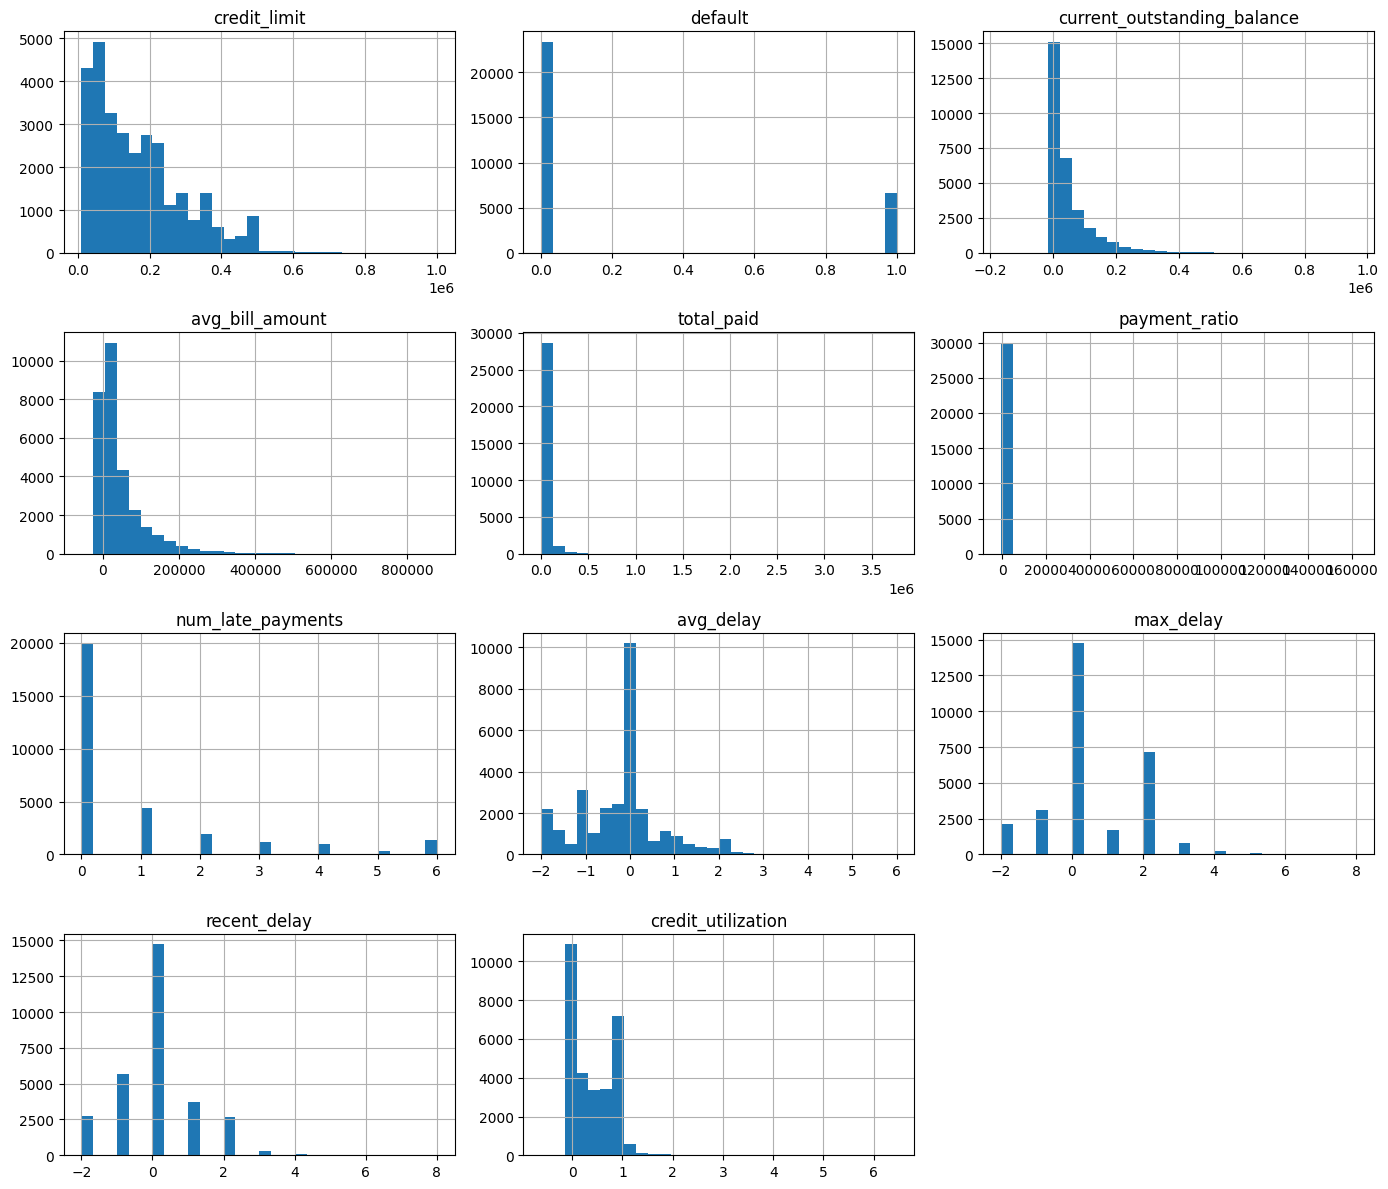

In [7]:
"""
Visualize distribution of all features
"""

credit_df.hist(figsize=(14, 12), bins=30)
plt.tight_layout()
plt.show()

In [9]:
"""
EDA: Feature Distribution Analysis

Most financial features such as credit_limit, avg_bill_amount, total_paid,
and current_outstanding_balance are heavily right-skewed. This indicates that
the majority of customers operate at lower credit levels, while a small portion
of customers have very high financial values.
""";

In [10]:
"""
EDA: Repayment Behavior Insights

Features like num_late_payments, avg_delay, and max_delay show that most
customers have little to no delay in payments. However, a smaller group exhibits
significant delays, which can act as strong indicators of default risk.
""";

In [11]:
"""
EDA: Recent Payment Behavior

The recent_delay feature shows variation in recent repayment activity.
While many customers pay on time, a noticeable portion have recent delays,
making this feature highly relevant for predicting default.
""";

In [12]:
"""
EDA: Credit Utilization Analysis

Most customers maintain credit utilization below 1, indicating controlled
credit usage. However, a subset of customers exceed their credit limits,
suggesting financial stress and higher likelihood of default.
""";

In [14]:
"""
EDA: Payment Ratio Observation

The payment_ratio is concentrated near lower values, indicating that many
customers repay only a small portion of their total outstanding bills.
This behavior may contribute to increased default risk.
""";


In [16]:
"""
EDA: Overall Insight

The dataset reveals clear behavioral patterns where most customers are
low-risk with stable repayment habits, while a smaller segment shows high
delays, high utilization, and weak repayment behavior, making them more
likely to default.
""";

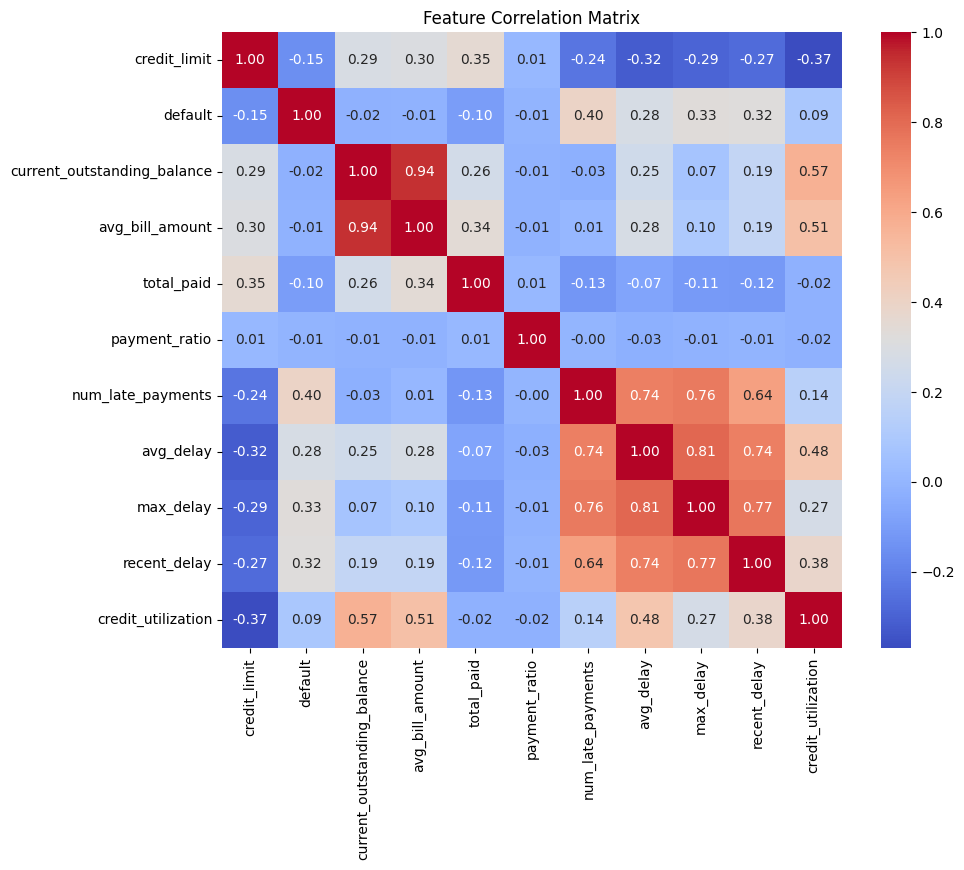

In [17]:
"""
Correlation matrix with target variable
"""

corr = credit_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [20]:
"""
EDA: Key Insight

Behavioral features, especially repayment delays, are the strongest predictors
of default, while raw financial features have weaker influence. This highlights
the importance of customer behavior over absolute financial values in credit
risk prediction.
""";

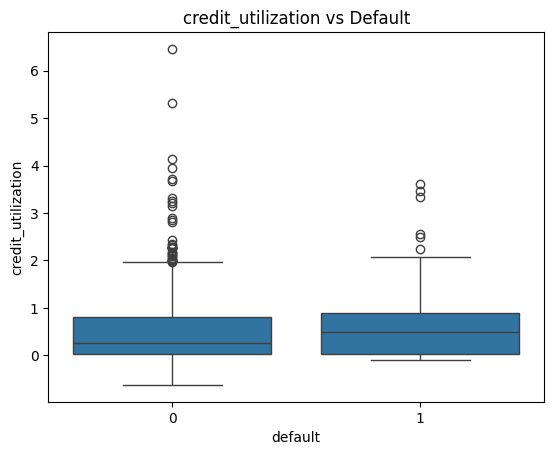

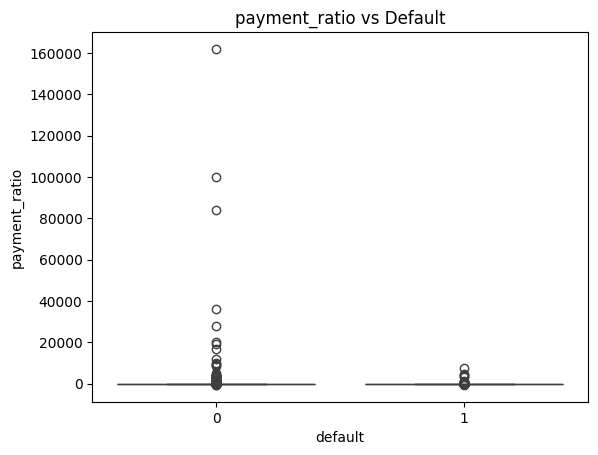

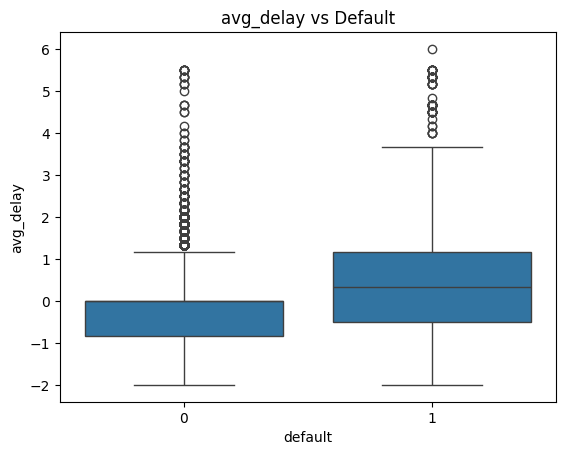

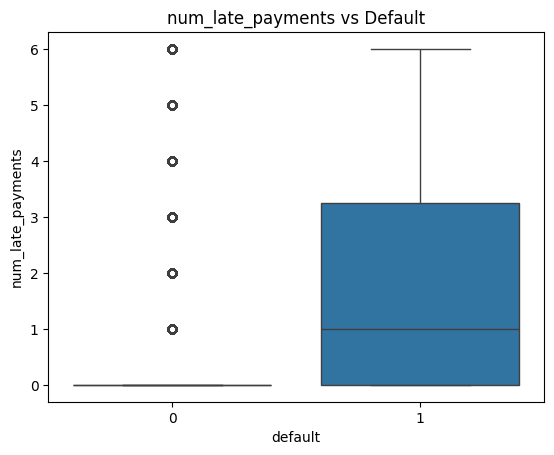

In [21]:
"""
Compare feature distributions for defaulters vs non-defaulters
"""

import seaborn as sns

features_to_check = [
    "credit_utilization",
    "payment_ratio",
    "avg_delay",
    "num_late_payments"
]

for feature in features_to_check:
    plt.figure()
    sns.boxplot(x="default", y=feature, data=credit_df)
    plt.title(f"{feature} vs Default")
    plt.show()

In [22]:
"""
EDA: Credit Utilization vs Default

Defaulters tend to have higher median credit utilization compared to
non-defaulters. This indicates that customers who use a larger portion
of their credit limit are more likely to default, reflecting higher
financial stress.
""";

In [23]:
"""
EDA: Payment Ratio vs Default

Both groups show low payment ratios overall, but defaulters tend to have
consistently lower repayment levels. This suggests that weaker repayment
behavior is associated with higher default risk.
""";

In [24]:
"""
EDA: Average Delay vs Default

Defaulters show significantly higher average delay values compared to
non-defaulters. This indicates that customers with frequent or prolonged
payment delays are much more likely to default.
""";

In [25]:
"""
EDA: Number of Late Payments vs Default

Defaulters clearly have a higher number of late payments, while most
non-defaulters have zero or very few delays. This highlights that repeated
late payments are a strong indicator of credit risk.
""";

In [26]:
"""
EDA: Key Behavioral Insight

Behavioral features such as repayment delays and late payment frequency
show strong separation between defaulters and non-defaulters, confirming
that customer payment behavior is a critical factor in predicting default.
""";